# Notebook 03: Machine Learning for Land Use Classification

**Goal:** Use Random Forest and U-Net to classify water bodies, vegetation, bare soil, and built-up areas — improving on the index-based approach from Notebook 02.

**For civil engineers:** ML automates what would take days of manual GIS digitization. It handles ambiguous cases (shadows, turbid water, mixed pixels) that simple thresholds miss.

**Author:** Dr. Sindhu | **Organization:** Smart Bhujal | **Contact:** sindhura@smartbhujal.com

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import os, sys

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
from utils import (
    compute_ndvi, compute_mndwi, compute_ndbi,
    make_rgb, plot_comparison, confusion_matrix_report,
    LAND_COVER_LABELS, LAND_COVER_CMAP, LAND_COVER_CLASSES
)

## Load data

In [2]:
data_path = os.path.join("..", "data", "sample", "bangalore_5band.tif")

with rasterio.open(data_path) as src:
    blue = src.read(1)
    green = src.read(2)
    red = src.read(3)
    nir = src.read(4)
    swir = src.read(5)

# Compute indices (same 3 as Notebook 02)
ndvi = compute_ndvi(nir, red)
mndwi = compute_mndwi(green, swir)
ndbi = compute_ndbi(swir, nir)
rgb = make_rgb(red, green, blue)

# Load threshold classification from Notebook 02
threshold_cls = np.load(os.path.join("..", "precomputed", "threshold_classification.npy"))
h, w = red.shape
print(f"Image: {h} x {w} pixels")

Image: 1683 x 2154 pixels


---
## Part A: Random Forest Classification

### The problem we're solving

In Notebook 02, we classified land cover using **hand-written rules**:
- "If MNDWI > 0, it's water"
- "If NDVI > 0.3, it's vegetation"

This worked reasonably well, but we saw limitations — shadows misclassified as water, turbid water missed, hard boundaries between classes.

**The ML approach:** Instead of us writing the rules, we show the computer **examples** of each class and let it figure out the rules itself.

```
Notebook 02 (thresholding):         Notebook 03 (ML):
  WE write the rules                  WE provide examples
  WE choose the thresholds            THE ALGORITHM learns the rules
  Rules are simple (if/else)          Rules can be complex and non-linear
```

### What is Machine Learning? (1-minute version)

1. We take pixels we've already classified (from Notebook 02's thresholding) — these are our **labeled examples**
2. For each pixel, we collect its **features** — the numbers that describe it
3. We feed features + labels into an algorithm that **learns the patterns**
4. The trained model can then classify **new pixels** it has never seen

```
Training:
  Labeled pixel → [Blue=320, Green=410, Red=280, NIR=120, SWIR=80, NDVI=-0.1, MNDWI=0.35, NDBI=-0.4]
                   → Label: WATER
  
  Thousands of these examples → Algorithm learns: "when MNDWI is high AND NIR is low → probably water"

Prediction:
  New pixel → [Blue=?, Green=?, Red=?, NIR=?, SWIR=?, NDVI=?, MNDWI=?, NDBI=?]
              → Model predicts: WATER (or VEGETATION or BARE SOIL or BUILT-UP)
```

### What are "features"?

A **feature** is a number that describes something about a pixel. The more informative features we give the model, the better it can distinguish classes.

We use **8 features per pixel**:

| Feature | What it tells the model |
|---------|------------------------|
| Blue (B02) | Raw brightness in blue light |
| Green (B03) | Raw brightness in green light |
| Red (B04) | Raw brightness in red light |
| NIR (B08) | Near-infrared reflectance — high for vegetation, low for water |
| SWIR (B11) | Shortwave infrared — high for buildings, low for water |
| NDVI | Vegetation index — combines NIR and Red |
| MNDWI | Water index — combines Green and SWIR |
| NDBI | Built-up index — combines SWIR and NIR |

The raw bands (Blue, Green, Red, NIR, SWIR) give the model the **raw measurements**. The indices (NDVI, MNDWI, NDBI) give it **pre-computed ratios** that we know are useful from domain knowledge.

### Where do the labels come from?

For this demo, we use the **threshold classification from Notebook 02** as our labels. In a real project, you would use:
- Manually digitized ground truth from field surveys
- Existing land use maps from government agencies
- Labels created by expert photo-interpreters from high-resolution imagery

The quality of your labels determines the quality of your model. Garbage in, garbage out.

### What is a Random Forest?

A **Decision Tree** asks a series of yes/no questions about the features:

```
                    Is MNDWI > 0.05?
                   /              \
                 YES               NO
                  |                 |
              WATER          Is NDVI > 0.35?
                            /              \
                          YES               NO
                           |                 |
                     VEGETATION       Is NDBI > 0.1?
                                     /              \
                                   YES               NO
                                    |                 |
                                BUILT-UP          BARE SOIL
```

A single tree is fragile — change the data slightly and the tree changes completely.

A **Random Forest** builds **100 trees**, each trained on a random subset of data. Each tree votes, and the **majority wins**.

```
   Tree 1: WATER     Tree 2: WATER     Tree 3: BUILT-UP    ...    Tree 100: WATER
                              ↓
                    Majority vote → WATER
```

**Why this works:** Individual trees make mistakes, but errors cancel out when you average 100 of them. Like asking 100 engineers for their opinion instead of just one.

### Other tree-based methods

| Method | How it differs |
|--------|---------------|
| **Decision Tree** | Single tree. Fast but unstable. |
| **Random Forest** | 100 trees voting in parallel. Our choice today. |
| **Gradient Boosting (XGBoost)** | Trees built sequentially, each fixing the previous one's mistakes. Often more accurate. |

### Let's build it step by step

In [3]:
# STEP 1: Build the feature stack
# For each pixel, we collect 8 numbers: 5 raw band values + 3 spectral indices
features = np.stack([blue, green, red, nir, swir, ndvi, mndwi, ndbi], axis=-1)
feature_names = ["Blue", "Green", "Red", "NIR", "SWIR", "NDVI", "MNDWI", "NDBI"]

print(f"Feature stack shape: {features.shape}")
print(f"  → {features.shape[0]} rows x {features.shape[1]} columns x {features.shape[2]} features per pixel")
print(f"  → Total pixels: {features.shape[0] * features.shape[1]:,}")
print(f"  → Features: {feature_names}")

# STEP 2: Get labels from Notebook 02's threshold classification
# Each pixel has a label: 0=Water, 1=Vegetation, 2=Bare Soil, 3=Built-up
print(f"\nLabels shape: {threshold_cls.shape}")
print(f"Label distribution:")
for class_id, (name, _) in LAND_COVER_CLASSES.items():
    count = (threshold_cls == class_id).sum()
    print(f"  {name:12s}: {count:>10,} pixels ({count/threshold_cls.size*100:.1f}%)")

# STEP 3: Flatten to a table (each row = one pixel, each column = one feature)
features_flat = features.reshape(-1, 8)   # shape: (num_pixels, 8)
labels_flat = threshold_cls.flatten()      # shape: (num_pixels,)
print(f"\nFlattened: {features_flat.shape[0]:,} pixels x {features_flat.shape[1]} features")

Feature stack shape: (1683, 2154, 8)
  → 1683 rows x 2154 columns x 8 features per pixel
  → Total pixels: 3,625,182
  → Features: ['Blue', 'Green', 'Red', 'NIR', 'SWIR', 'NDVI', 'MNDWI', 'NDBI']

Labels shape: (1683, 2154)
Label distribution:
  Water       :     62,787 pixels (1.7%)
  Vegetation  :    426,636 pixels (11.8%)
  Bare Soil   :    856,671 pixels (23.6%)
  Built-up    :  2,279,088 pixels (62.9%)

Flattened: 3,625,182 pixels x 8 features


### Visualize: what does the model "see" for each class?

Each class has a distinct **fingerprint** — a pattern of feature values. Let's look at one example pixel from each class:

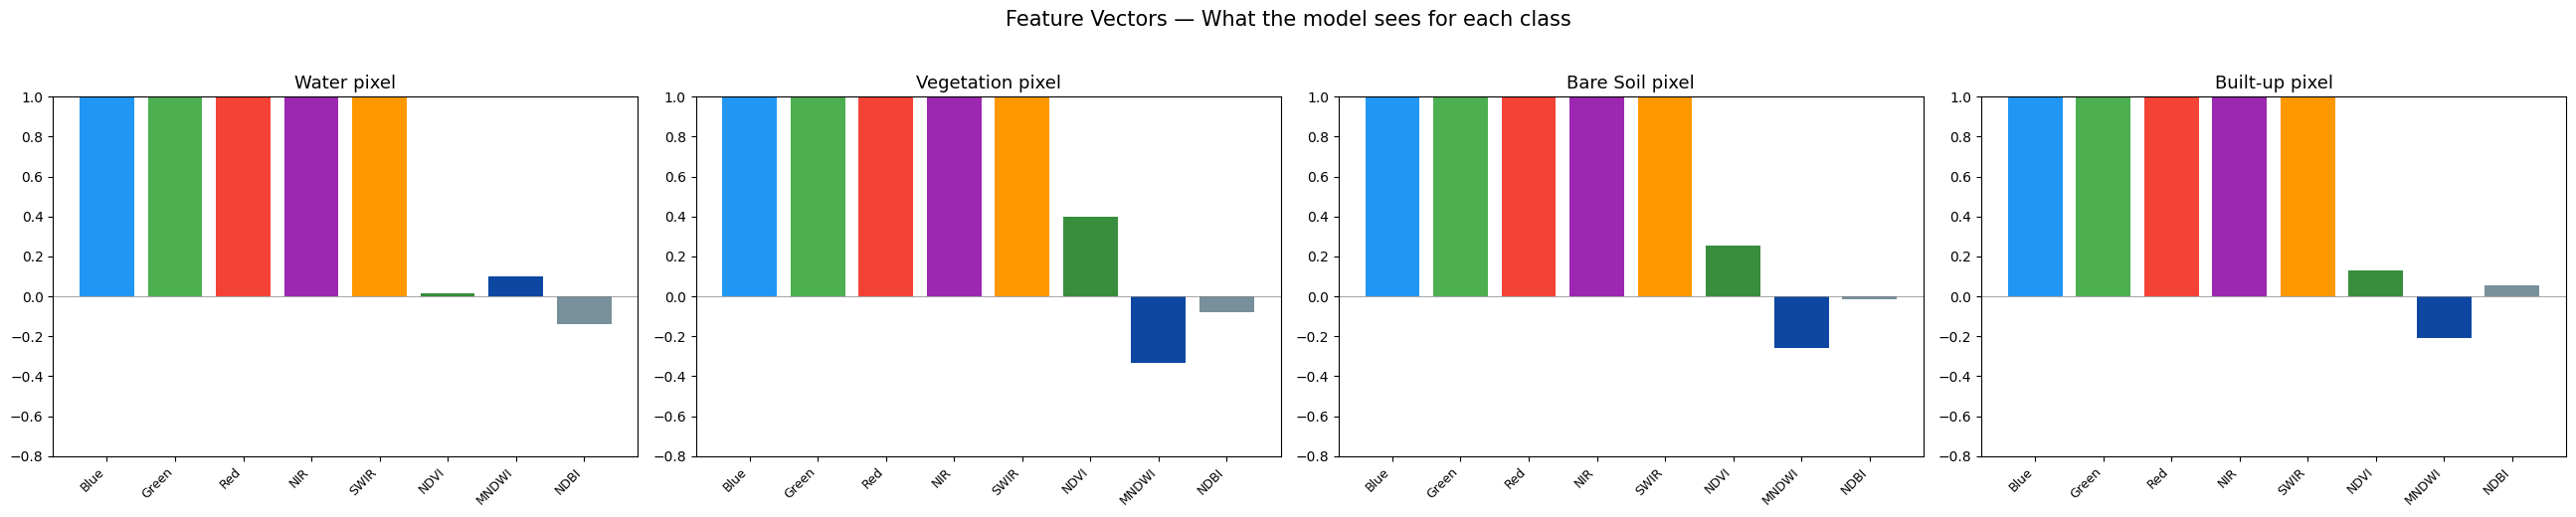

Key observations:
  Water:      HIGH MNDWI, LOW NIR/SWIR (water absorbs these)
  Vegetation: HIGH NDVI, HIGH NIR (plants reflect NIR)
  Built-up:   HIGH NDBI, HIGH SWIR (buildings reflect SWIR)
  The model learns these patterns from thousands of examples


In [4]:
# Visualize what a feature vector looks like for different land cover types
np.random.seed(42)
example_pixels = {}
for class_id, (class_name, _) in LAND_COVER_CLASSES.items():
    mask = threshold_cls == class_id
    ys, xs = np.where(mask)
    idx = np.random.randint(len(ys))
    r, c = ys[idx], xs[idx]
    example_pixels[class_name] = features[r, c, :]

fig, axes = plt.subplots(1, 4, figsize=(26, 5))
bar_colors = ["#2196F3", "#4CAF50", "#F44336", "#9C27B0", "#FF9800",
              "#388E3C", "#0D47A1", "#78909C"]

for ax, (name, feat_vec) in zip(axes, example_pixels.items()):
    ax.bar(range(8), feat_vec, color=bar_colors)
    ax.set_xticks(range(8))
    ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=9)
    ax.set_title(f"{name} pixel", fontsize=13)
    ax.set_ylim(-0.8, 1.0)
    ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)

plt.suptitle("Feature Vectors — What the model sees for each class", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  Water:      HIGH MNDWI, LOW NIR/SWIR (water absorbs these)")
print("  Vegetation: HIGH NDVI, HIGH NIR (plants reflect NIR)")
print("  Built-up:   HIGH NDBI, HIGH SWIR (buildings reflect SWIR)")
print("  The model learns these patterns from thousands of examples")

### Sample pixels and split into training / test sets

We have ~3.6 million pixels — too many to train on efficiently. We randomly sample 50,000 pixels, then split them:
- **70% for training** — the model learns from these
- **30% for testing** — we check accuracy on pixels the model has **never seen**

This prevents **overfitting** — where the model memorizes the training data but fails on new data.

In [5]:
# STEP 4: Sample 50,000 random pixels (we don't need all 3.6M)
np.random.seed(42)
n_samples = 50000
sample_indices = np.random.choice(len(labels_flat), n_samples, replace=False)

X = features_flat[sample_indices]  # shape: (50000, 8)
y = labels_flat[sample_indices]    # shape: (50000,)

# STEP 5: Split into training (70%) and test (30%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} pixels")
print(f"Test set:     {len(X_test):,} pixels")
print(f"Features per pixel: {X_train.shape[1]}")

Training set: 35,000 pixels
Test set:     15,000 pixels
Features per pixel: 8


### Train the Random Forest

Now we feed the training data (features + labels) into a Random Forest with 100 trees. The algorithm automatically learns which feature combinations correspond to which class.

In [6]:
%%time
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
confusion_matrix_report(y_test, y_pred)

Test Accuracy: 1.000

Confusion Matrix:
[[ 249    1    2    0]
 [   0 1762    0    0]
 [   0    1 3575    0]
 [   0    0    1 9409]]

              precision    recall  f1-score   support

       Water       1.00      0.99      0.99       252
  Vegetation       1.00      1.00      1.00      1762
   Bare Soil       1.00      1.00      1.00      3576
    Built-up       1.00      1.00      1.00      9410

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000

CPU times: user 3.46 s, sys: 66.1 ms, total: 3.53 s
Wall time: 423 ms


array([[ 249,    1,    2,    0],
       [   0, 1762,    0,    0],
       [   0,    1, 3575,    0],
       [   0,    0,    1, 9409]])

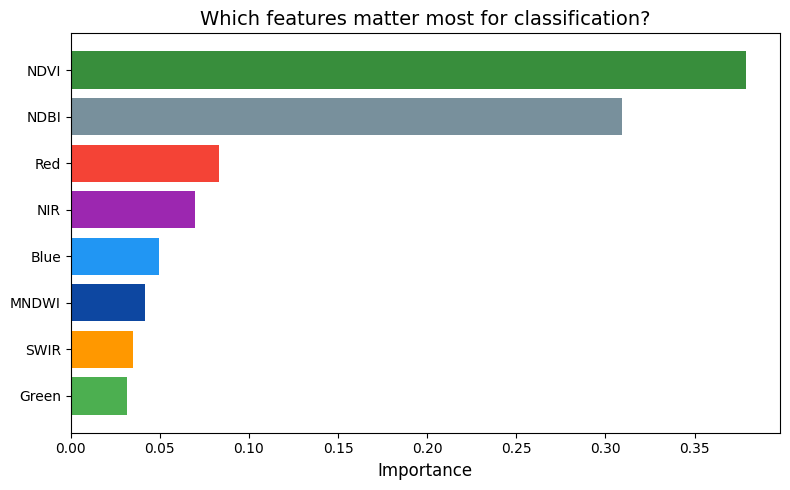

Notice: MNDWI is likely a top feature — confirming that the water index
is critical for land use classification in urban watersheds.


In [7]:
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2196F3", "#4CAF50", "#F44336", "#9C27B0", "#FF9800",
          "#388E3C", "#0D47A1", "#78909C"]
ax.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx],
        color=[colors[i] for i in sorted_idx])
ax.set_xlabel("Importance", fontsize=12)
ax.set_title("Which features matter most for classification?", fontsize=14)
plt.tight_layout()
plt.show()

print("Notice: MNDWI is likely a top feature — confirming that the water index")
print("is critical for land use classification in urban watersheds.")

### Reading the feature importance chart

Feature importance tells us: **if we removed this feature, how much worse would the model get?**

High importance = the model relies heavily on this feature. This is valuable because:
1. It **validates domain knowledge** — if MNDWI ranks high, it confirms what water engineers know
2. It guides **data collection** — you know which bands are essential
3. It helps **debugging** — if an irrelevant feature ranks high, something is wrong

### Classify the full image

Now we apply the trained model to **every pixel** in the image:

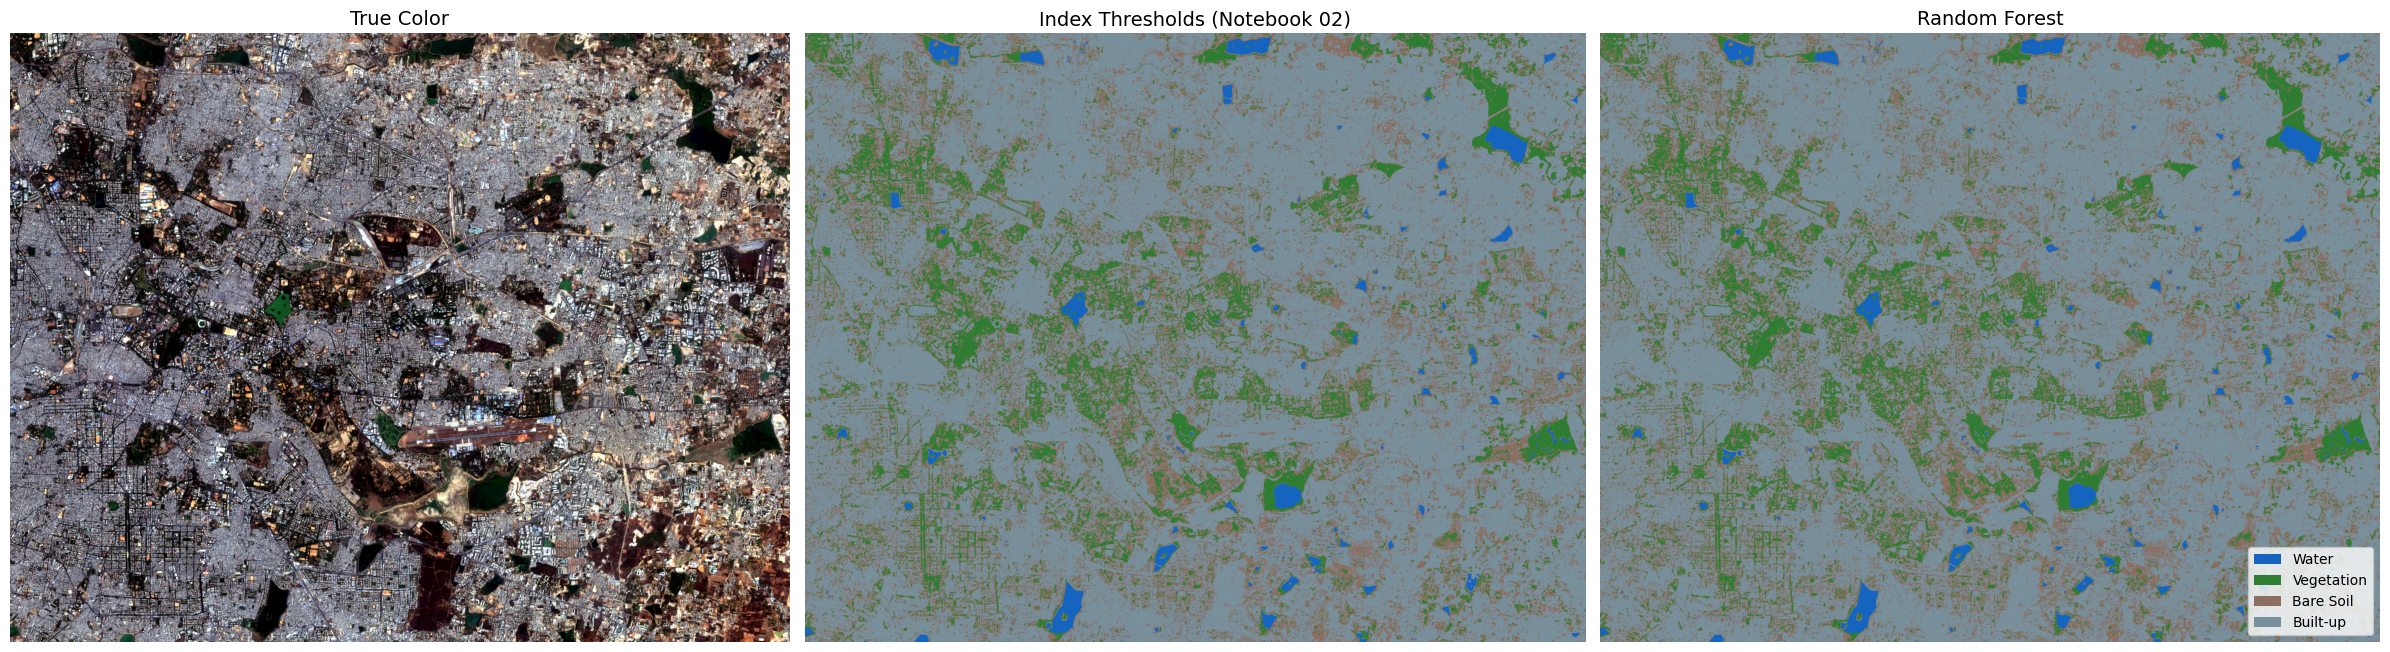

CPU times: user 11.4 s, sys: 1.13 s, total: 12.5 s
Wall time: 2.63 s


In [8]:
%%time
rf_classification = rf.predict(features_flat).reshape(h, w)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

axes[0].imshow(rgb)
axes[0].set_title("True Color", fontsize=14)
axes[0].axis("off")

axes[1].imshow(threshold_cls, cmap=LAND_COVER_CMAP, vmin=0, vmax=3)
axes[1].set_title("Index Thresholds (Notebook 02)", fontsize=14)
axes[1].axis("off")

axes[2].imshow(rf_classification, cmap=LAND_COVER_CMAP, vmin=0, vmax=3)
axes[2].set_title("Random Forest", fontsize=14)
axes[2].axis("off")

patches = [plt.Rectangle((0, 0), 1, 1, fc=c) for _, (_, c) in LAND_COVER_CLASSES.items()]
axes[2].legend(patches, LAND_COVER_LABELS, loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

### Limitation of Random Forest: No spatial awareness

Look closely at the Random Forest output — it has a **salt-and-pepper** appearance. Individual pixels are misclassified because Random Forest treats each pixel **independently**. It doesn't know that a pixel is surrounded by water pixels.

Imagine labeling a map one pixel at a time vs. looking at the whole neighborhood. That's the difference between Random Forest and deep learning.

---
## Part B: U-Net — Deep Learning for Pixel-level Classification

### From pixels to patches: why spatial context matters

Consider a dark pixel. Is it:
- A shadow on a building?
- A deep lake?
- A dark rooftop?

The pixel values might be identical. But if you zoom out and see the dark pixel is **surrounded by water pixels** and has a **smooth boundary**, it's probably water. If it's **surrounded by buildings** and has **sharp edges**, it's probably a shadow.

This is **spatial context** — and it's what neural networks can learn.

### What is a Convolutional Neural Network (CNN)?

A CNN slides a small window (e.g., 3x3 pixels) across the image and learns **local patterns**:

```
Image:                      3x3 Filter:          Output:
┌───┬───┬───┬───┐          ┌───┬───┬───┐        
│ 2 │ 1 │ 3 │ 0 │          │-1 │ 0 │ 1 │        The filter detects
│ 5 │ 4 │ 2 │ 1 │    *     │-1 │ 0 │ 1 │   →    edges, textures,
│ 1 │ 3 │ 6 │ 2 │          │-1 │ 0 │ 1 │        and patterns
│ 0 │ 2 │ 1 │ 4 │          └───┴───┴───┘        
└───┴───┴───┴───┘                                
```

The network stacks many such filters to learn increasingly complex patterns:
- **Layer 1:** Edges, color gradients
- **Layer 2:** Textures (smooth water surface, rough building texture)
- **Layer 3:** Object parts (lake boundary, road segment)
- **Deeper layers:** Full objects and context

### U-Net Architecture

U-Net is a specific CNN architecture designed for **semantic segmentation** — classifying every pixel. It has two halves:

```
INPUT (128 x 128 x 5 bands)
   │
   ▼
┌─────────────┐
│  ENCODER    │  Shrinks the image, extracts "what" features
│  (ResNet34) │  128→64→32→16→8  (gets smaller but deeper)
│             │  Learns: "this region contains water"
└──────┬──────┘
       │
       ▼
┌─────────────┐
│ BOTTLENECK  │  Smallest representation (8 x 8)
│             │  Maximum understanding, minimum spatial detail
└──────┬──────┘
       │
       ▼
┌─────────────┐
│  DECODER    │  Grows the image back, recovers "where" details
│             │  8→16→32→64→128  (gets bigger, finer detail)
│             │  Learns: "the water boundary is exactly here"
└──────┬──────┘
       │
       ▼
OUTPUT (128 x 128 x 4 classes)

   ╔═══════════════════════════════════════╗
   ║  SECRET SAUCE: Skip Connections       ║
   ║                                       ║
   ║  Encoder ──────────────────► Decoder  ║
   ║  (at each level)                      ║
   ║                                       ║
   ║  These pass spatial details directly  ║
   ║  from encoder to decoder, so fine     ║
   ║  boundaries aren't lost.              ║
   ╚═══════════════════════════════════════╝
```

**Analogy:** The encoder is like looking at a map from far away (you see the big picture but lose detail). The decoder zooms back in. Skip connections are like having notes from the zoomed-in view that you pass forward.

### Other segmentation architectures you should know

| Architecture | Key idea | When to use |
|-------------|----------|-------------|
| **U-Net** | Encoder-decoder with skip connections | Standard choice, works great for most tasks |
| **DeepLabV3+** | Uses "dilated convolutions" to see wider context | When objects vary greatly in size |
| **SegFormer** | Transformer-based (like GPT but for images) | State of the art, needs more data |
| **FPN (Feature Pyramid Network)** | Multi-scale feature fusion | When you need to detect both large lakes and small ponds |

For satellite land cover classification, **U-Net is the most popular** starting point. It's proven, well-documented, and works well even with limited training data.

### Why we use a pre-trained encoder (Transfer Learning)

Our U-Net uses a **ResNet-34 encoder pre-trained on ImageNet** (1.2 million natural photographs). Even though those photos aren't satellite images, the low-level features (edges, textures, color patterns) are similar enough to be useful.

This is **transfer learning** — reusing knowledge from one task for another. It means:
- We need **less training data** (the encoder already knows edges and textures)
- Training is **faster** (we only need to fine-tune, not learn from scratch)
- Results are **better** than training from random initialization

### Let's build and train it

In [9]:
import torch
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=5,        # 5 bands: Blue, Green, Red, NIR, SWIR
    classes=4,            # Water, Vegetation, Bare Soil, Built-up
    activation=None,
)

total_params = sum(p.numel() for p in model.parameters())
print(f"U-Net (ResNet-34 encoder): {total_params:,} parameters")

U-Net (ResNet-34 encoder): 24,443,076 parameters


In [10]:
# Normalize bands to 0-1
image_stack = np.stack([blue, green, red, nir, swir], axis=0).astype(np.float32)
for i in range(5):
    band = image_stack[i]
    valid = band[band > 0]
    if len(valid) > 0:
        p2, p98 = np.percentile(valid, (2, 98))
        image_stack[i] = np.clip((band - p2) / (p98 - p2 + 1e-10), 0, 1)

class PatchDataset(Dataset):
    def __init__(self, image, labels, patch_size=128, n_patches=500):
        self.image = image
        self.labels = labels
        self.ps = patch_size
        _, self.h, self.w = image.shape
        np.random.seed(42)
        self.rows = np.random.randint(0, self.h - patch_size, n_patches)
        self.cols = np.random.randint(0, self.w - patch_size, n_patches)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r, c = self.rows[idx], self.cols[idx]
        return (torch.from_numpy(self.image[:, r:r+self.ps, c:c+self.ps]),
                torch.from_numpy(self.labels[r:r+self.ps, c:c+self.ps]).long())

dataset = PatchDataset(image_stack, threshold_cls, patch_size=128, n_patches=600)
loader = DataLoader(dataset, batch_size=8, shuffle=True)
print(f"Training: {len(dataset)} patches of 128x128 pixels")

Training: 600 patches of 128x128 pixels


### How training works — the learning loop

Training a neural network is an iterative process:

```
For each epoch (pass through the data):
    For each batch of patches:
        1. FORWARD:  Feed patch through the network → get prediction
        2. LOSS:     Compare prediction to ground truth → compute error
        3. BACKWARD: Calculate how to adjust each weight to reduce error
        4. UPDATE:   Nudge all weights slightly in the right direction
```

- **Epoch** = one complete pass through all training patches
- **Loss** = how wrong the predictions are (lower is better)
- **Learning rate** = how big each weight adjustment is (too big → unstable, too small → slow)

We train for 5 epochs — enough to see the loss drop significantly.

In [11]:
%%time
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

model.train()
for epoch in range(5):
    epoch_loss = 0
    for batch_img, batch_lbl in loader:
        preds = model(batch_img)
        loss = loss_fn(preds, batch_lbl)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/5 — Loss: {epoch_loss/len(loader):.4f}")

print("\nTraining complete!")

Epoch 1/5 — Loss: 0.6052
Epoch 2/5 — Loss: 0.4082
Epoch 3/5 — Loss: 0.3444
Epoch 4/5 — Loss: 0.3332
Epoch 5/5 — Loss: 0.3213

Training complete!
CPU times: user 5min 32s, sys: 36.5 s, total: 6min 8s
Wall time: 1min 42s


In [12]:
%%time
model.eval()
input_tensor = torch.from_numpy(image_stack).unsqueeze(0)
_, _, ih, iw = input_tensor.shape
patch_size = 512
output = torch.zeros(1, 4, ih, iw)

with torch.no_grad():
    for y in range(0, ih, patch_size):
        for x in range(0, iw, patch_size):
            ye, xe = min(y + patch_size, ih), min(x + patch_size, iw)
            patch = input_tensor[:, :, y:ye, x:xe]
            ph, pw = patch.shape[2], patch.shape[3]
            pad_h = (32 - ph % 32) % 32
            pad_w = (32 - pw % 32) % 32
            if pad_h > 0 or pad_w > 0:
                patch = torch.nn.functional.pad(patch, (0, pad_w, 0, pad_h))
            pred = model(patch)
            output[:, :, y:ye, x:xe] = pred[:, :, :ph, :pw]

unet_classification = output.argmax(dim=1).squeeze().numpy()
print(f"U-Net prediction: {unet_classification.shape}")
print(f"Classes found: {np.unique(unet_classification)}")

U-Net prediction: (1683, 2154)
Classes found: [0 1 2 3]
CPU times: user 8.83 s, sys: 466 ms, total: 9.3 s
Wall time: 2.41 s


### Important caveat: we're training and testing on the same image

In this demo, we train on patches from one image and predict on the same image. In a real project, this is **not enough** — the model might just memorize this specific image.

**For a production system, you would:**
- Train on images from **multiple dates or locations**
- Test on a **completely separate image** the model has never seen
- Validate against **field survey data** or manually digitized ground truth

**Why we do it this way here:** This is an introduction to the tools and workflow. Adding multiple images would triple the notebook complexity. The concepts (features, training, inference) are the same — you'd just use more data.

**What you should do in your own project:**
1. Download images from 2-3 different dates using Notebook 01 (just change the date range)
2. Train on dates 1 and 2, test on date 3
3. Compare the model's predictions against known ground truth

### Side-by-side: All three approaches

Look at the differences:
- **Thresholds**: Sharp, rule-based boundaries. Noisy edges.
- **Random Forest**: Similar to thresholds (both pixel-based), but learns flexible non-linear boundaries.
- **U-Net**: Smoothest boundaries, most spatially coherent — uses neighborhood information.

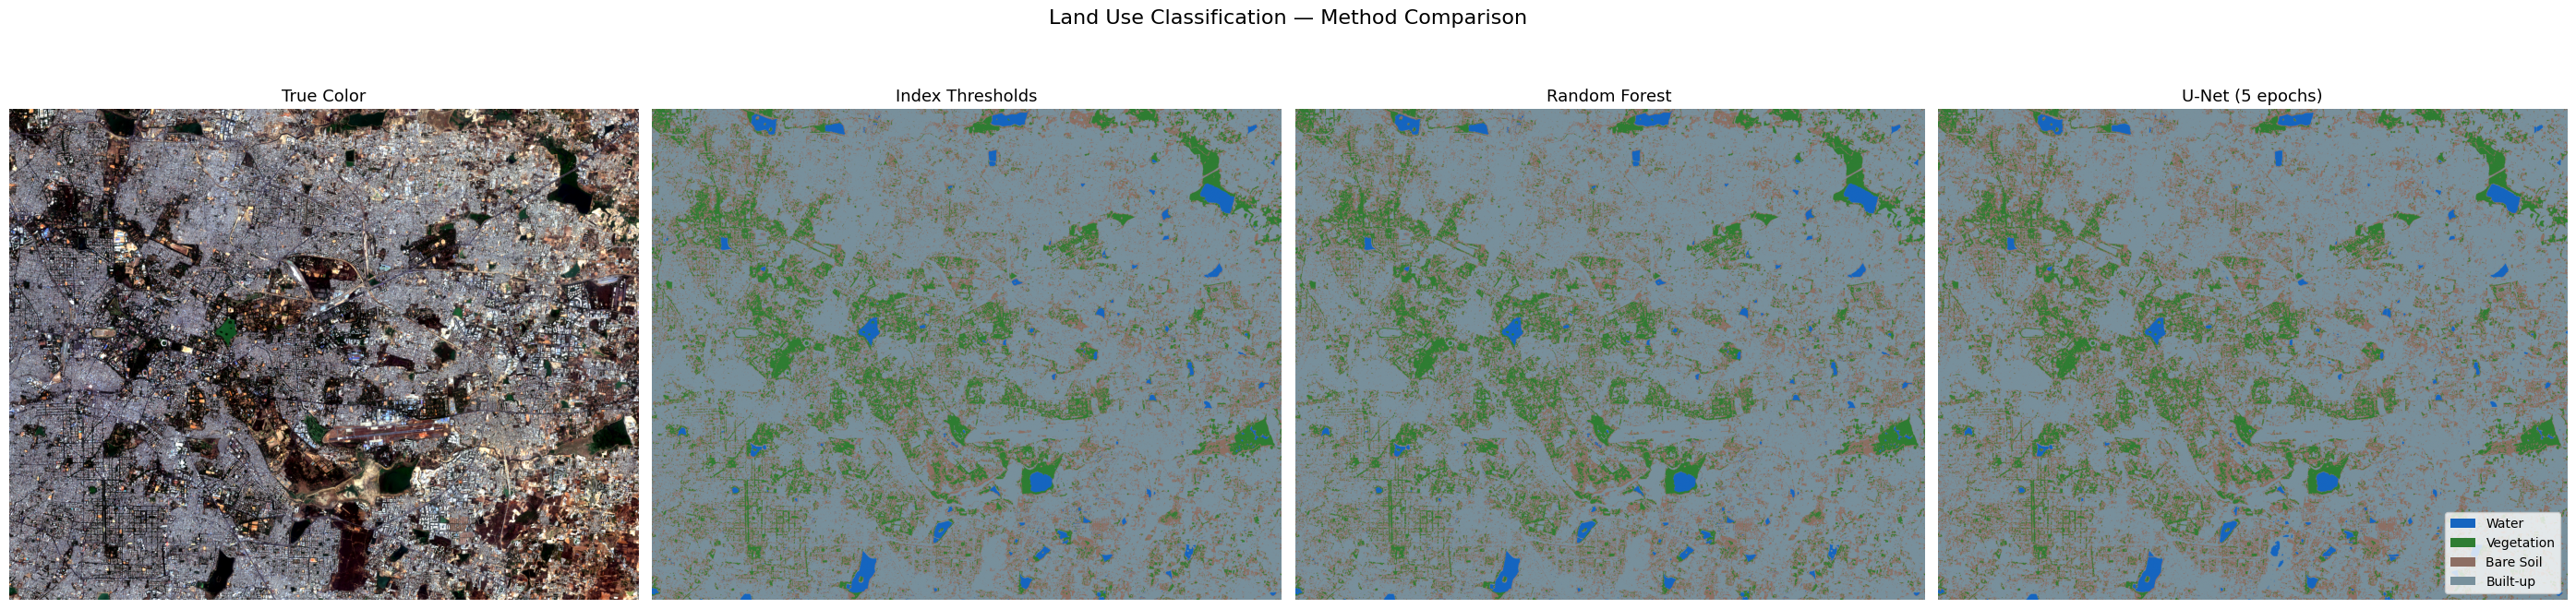

  Thresholds     : Water area = 6.28 km²
  Random Forest  : Water area = 6.23 km²
  U-Net          : Water area = 5.58 km²


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(28, 7))

axes[0].imshow(rgb)
axes[0].set_title("True Color", fontsize=13)
axes[0].axis("off")

axes[1].imshow(threshold_cls, cmap=LAND_COVER_CMAP, vmin=0, vmax=3)
axes[1].set_title("Index Thresholds", fontsize=13)
axes[1].axis("off")

axes[2].imshow(rf_classification, cmap=LAND_COVER_CMAP, vmin=0, vmax=3)
axes[2].set_title("Random Forest", fontsize=13)
axes[2].axis("off")

axes[3].imshow(unet_classification, cmap=LAND_COVER_CMAP, vmin=0, vmax=3)
axes[3].set_title("U-Net (5 epochs)", fontsize=13)
axes[3].axis("off")

patches = [plt.Rectangle((0, 0), 1, 1, fc=c) for _, (_, c) in LAND_COVER_CLASSES.items()]
axes[3].legend(patches, LAND_COVER_LABELS, loc="lower right", fontsize=10)

plt.suptitle("Land Use Classification — Method Comparison", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Water area comparison
for name, cls_map in [("Thresholds", threshold_cls), ("Random Forest", rf_classification), ("U-Net", unet_classification)]:
    water_pixels = (cls_map == 0).sum()
    water_km2 = water_pixels * (10**2) / 1e6
    print(f"  {name:15s}: Water area = {water_km2:.2f} km²")

In [14]:
np.save(os.path.join("..", "precomputed", "rf_classification.npy"), rf_classification)
np.save(os.path.join("..", "precomputed", "unet_classification.npy"), unet_classification)

# Save U-Net weights for reuse
weights_dir = os.path.join("..", "models", "pretrained")
os.makedirs(weights_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(weights_dir, "unet_landcover.pth"))
print("Saved classifications and U-Net weights.")

Saved classifications and U-Net weights.


## Summary: The ML Landscape for Satellite Classification

```
SIMPLEST                                                         MOST POWERFUL
   │                                                                    │
   ▼                                                                    ▼
Thresholds → Decision Tree → Random Forest → Gradient Boosting → U-Net → SegFormer
                                                                         
  No ML         Classical ML (pixel-based)           Deep Learning (patch-based)
  
  Fast, simple    Fast, interpretable                 Slower, needs GPU for training
  No training     Needs labeled data                  Needs more labeled data
  Brittle         Good generalization                 Best accuracy + spatial context
```

### Which method should you use?

| Your situation | Recommended method |
|---------------|-------------------|
| Quick field assessment, single image | Index thresholds (Notebook 02) |
| Regular monitoring, small labeled dataset | Random Forest (this notebook) |
| Production mapping, need precise boundaries | U-Net (this notebook) |
| New area, very limited labels | Foundation model (Notebook 04) |
| Maximum accuracy, have GPU + lots of data | DeepLabV3+ or SegFormer |

## Key Takeaways

1. **ML replaces manual rule-writing** — the algorithm learns thresholds from data
2. **Feature engineering matters** — giving the model spectral indices (not just raw bands) improves accuracy significantly
3. **Random Forest** is fast, interpretable, and a great starting point — feature importance validates domain knowledge
4. **U-Net** adds spatial context — smoother boundaries, fewer misclassifications at edges
5. **Transfer learning** (pre-trained encoder) means you don't need millions of training samples
6. For water resources: ML gives more **reliable, repeatable** water body boundaries than manual methods

**Next:** In Notebook 04, we explore foundation models — AI pre-trained on millions of images that requires even less labeled data from you.